# Microbial Abundance Analysis

Reference-based microbial abundance, richness, prevalence, particle-load, and core-genus analyses for the wheat phyllosphere manuscript.


## 1. Setup


### 1.1 Imports and Plot Settings


In [31]:
import glob
import os
from collections import defaultdict
from io import StringIO

import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.colors as colors
from Bio import Phylo
import matplotlib.pyplot as plt

sns.set_style("ticks", {'axes.grid': True})
sns.set_palette("colorblind")
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["xtick.major.width"] = 1.5
plt.rcParams["ytick.major.width"] = 1.5
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["axes.titlepad"] = 7
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["axes.titlesize"] = 8
plt.rcParams["axes.labelsize"] = 7
plt.rcParams["xtick.labelsize"] = 7
plt.rcParams["ytick.labelsize"] = 7
plt.rcParams["legend.fontsize"] = 7
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Liberation Sans"]
plt.rcParams["text.usetex"] = False
plt.rcParams["savefig.dpi"] = 300

points_to_inches = 0.0138889


In [32]:
# Load list of samples
work_dir="/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/"
qc_read_counts=work_dir +'/FIGURES_AND_TABLES/01_qc_read_counts_paired.tot.csv'
DNA_metadata_file="/home/lmf/PhylloVir/VIRAL_WORLD/DNA_extraction_metadata.tsv"
desired_ranks = ['superkingdom','kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']
metadata_file="/home/lmf/PhylloVir/VIRAL_WORLD/metadata_samples.txt"


### 1.2 Reusable Functions


In [37]:
def top_columns(row, num_columns=5):
    # Return the top N taxa (columns) with the highest abundance in a row
    sorted_columns = row.sort_values(ascending=False).index.tolist()
    return sorted_columns[:num_columns]

def filter_top_taxa_particles(taxonomy_df_original,top_taxa):
    # Same as filter_top_taxa, but without "Unclassified"
    taxonomy_df=taxonomy_df_original.copy()
    
    # Find top taxa per sample
    top_columns_df = taxonomy_df.apply(top_columns, num_columns=top_taxa, axis=1)
    top_columns_df = top_columns_df.to_frame()
    
    # Flatten into a unique list of top taxa
    top_taxa_list = pd.concat([top_columns_df[0]], ignore_index=True).tolist()
    top_taxa_list = [item for sublist in top_taxa_list for item in sublist]
    top_taxa_list = list(set(top_taxa_list))
    print(len(top_taxa_list))
    
    # Collapse remaining taxa into "Other"
    if len(taxonomy_df)>top_taxa:
        taxonomy_df["Other"]=taxonomy_df.drop(columns=top_taxa_list).T.sum()
        top_taxa_list.append("Other")
        taxonomy_df=taxonomy_df[top_taxa_list]

        if "N/A" in taxonomy_df.columns.to_list():
            taxonomy_df["Other"]=taxonomy_df["Other"] + taxonomy_df["N/A"]
            taxonomy_df=taxonomy_df.drop("N/A", axis=1)
    else:
        if "N/A" in taxonomy_df.columns.to_list():
            taxonomy_df["Other"]=taxonomy_df["N/A"]
            taxonomy_df=taxonomy_df.drop("N/A", axis=1)
         
    # Reorder columns by mean abundance
    column_averages = taxonomy_df.mean().sort_values(ascending=False)
    taxonomy_df = taxonomy_df[column_averages.index]
    
    # Move "Other" to the end
    columns_to_move=[]
    if "Other" in taxonomy_df.columns:
        columns_to_move.append("Other")
        
    taxonomy_df = taxonomy_df[[col for col in taxonomy_df.columns if col not in columns_to_move] + columns_to_move]
    return taxonomy_df

    
def plot_stackplot_dict(taxonomy_df, group_dict, figsize=None, show=True):
    # Plot stackplots grouped by dictionary of samples → groups
    sns.set(style="whitegrid")
    
    # Fixed color palette
    color_palette = ["#1F77B4", "#AEC7E8", "#FF7F0E", "#FFBB78", "#2CA02C", "#98DF8A", 
                     "#D62728", "#FF9896", "#C5B0D5", "#8C564B", "#C49C94", "#E377C2", 
                     "#F7B6D2", "#7F7F7F", "#C7C7C7", "#BCBD22", "#DBDB8D", "#17BECF", "#9EDAE5"]
    
    unique_groups = list(group_dict.keys())  # Group names
    group_sizes = [len(members) for members in group_dict.values()]  # Group sizes

    def clean_taxon_label(label):
        return str(label).replace("Candidatus", "Ca.").replace("Canditatus", "Ca.")
    
    # One subplot per group
    if figsize is None:
        figsize = (sum(group_sizes) * 0.4, 8)

    fig, axes = plt.subplots(1, len(unique_groups), 
                             figsize=figsize, 
                             gridspec_kw={'width_ratios': group_sizes}, 
                             sharey=True)
    axes = np.atleast_1d(axes)
    
    for i, group in enumerate(unique_groups):
        members = group_dict[group]  # Samples in this group
        group_df = taxonomy_df.loc[members]  # Subset dataframe
        
        samples = group_df.index
        categories = group_df.columns
        category_labels = [clean_taxon_label(category) for category in categories]
        values = group_df.T.values
        
        axes[i].stackplot(samples, values, labels=category_labels, 
                          colors=color_palette, edgecolor='none')
        
        axes[i].set_title(str(group).replace(" ", "\n"))
        axes[i].set_ylim(0, 100)
        axes[i].tick_params(axis='x', rotation=90)
        
        if i == 0:
            axes[i].set_ylabel('Relative abundance (%)', fontweight="bold")
        if i == len(unique_groups) // 2:
            axes[i].set_xlabel('Sample', fontweight="bold")
        if i == len(unique_groups) - 1:
            legend = axes[i].legend(title=taxonomy_df.columns.name or "Taxonomic rank", loc='upper left', bbox_to_anchor=(1, 1), labelspacing=0.15, handletextpad=0.4, borderaxespad=0.2)
            legend.get_title().set_fontweight("bold")
            legend.get_title().set_fontsize(9)
            for text in legend.get_texts():
                text.set_fontstyle("italic")
                text.set_fontsize(9)
                
    
    plt.tight_layout()
    if show:
        plt.show()
    return fig, axes
    
def plot_stackplot_dict_reads(taxonomy_df, group_dict, figname):
    # Plot stackplots of sequenced reads grouped by dictionary of samples → groups
    sns.set(style="whitegrid")
    
    # Fixed mapping of categories to colors
    category_colors = {
        "strain collection": "#17BECF",
        "non strain collection": "#9EDAE5",
        "microbial": "#9EDAE5",
        "plant": "#DBDB8D",
        "unclassified": "#808080"
    }
    
    unique_groups = list(group_dict.keys())
    group_sizes = [len(members) for members in group_dict.values()]
    
    fig, axes = plt.subplots(
        1, len(unique_groups),
        figsize=(sum(group_sizes) * 0.3, 4),
        gridspec_kw={'width_ratios': group_sizes},
        sharey=True
    )
    
    for i, group in enumerate(unique_groups):
        members = group_dict[group]
        group_df = taxonomy_df.loc[members]  # Subset dataframe
        
        samples = group_df.index
        categories = group_df.columns
        values = group_df.T.values
        
        # Get colors for categories, default if missing
        colors = [category_colors.get(cat, "#BCBD22") for cat in categories]
        
        axes[i].stackplot(samples, values, labels=categories, 
                          colors=colors, edgecolor='none')
        
        axes[i].set_title(str(group).replace(" ", "\n"))
        axes[i].set_ylim(0, 100)
        axes[i].tick_params(axis='x', rotation=90)
        
        if i == 0:
            axes[i].set_ylabel('Sequenced bases (%)', fontweight="bold")
        if i == len(unique_groups) // 2:
            axes[i].set_xlabel('Sample', fontweight="bold")
        if i == len(unique_groups) - 1:
            legend = axes[i].legend(title="Origin", loc='upper left', bbox_to_anchor=(1, 1), labelspacing=0.15, handletextpad=0.4, borderaxespad=0.2)
            legend.get_title().set_fontweight("bold")
            legend.get_title().set_fontsize(9)
            for text in legend.get_texts():
                text.set_fontsize(9)
    
    plt.tight_layout()
    plt.savefig(figname)  # Save figure to file
    plt.show()

def pick_representative(cluster):
    """Select one representative genome from an ANI cluster."""
    candidates = cluster.intersection(strain_list)
    if not candidates:
        candidates = cluster

    return max(candidates, key=lambda g: genome_lengths.loc[g, "genome_size"])

def prevalence_groups(microbial_taxa_df_relative, taxa_level):
    if taxa_level=="species":
        n=1
    if taxa_level=="genus":
        n=2
    if taxa_level=="family":
        n=3
    if taxa_level=="order":
        n=4
    if taxa_level=="class":
        n=5
    if taxa_level=="phylum":
        n=6        
    # Calculating the percentage of samples above each threshold for each species
    filtered_microbial_taxa_df_relative=microbial_taxa_df_relative.drop(['N/A'], errors='ignore')
    filtered_microbial_taxa_df_relative
    prevalence_bacterial_taxa = pd.DataFrame({threshold: (filtered_microbial_taxa_df_relative[SAMPLES].T > threshold).mean()*100 for threshold in thresholds})
    prevalence_bacterial_taxa["mean"]=filtered_microbial_taxa_df_relative.T.mean()
    prevalence_bacterial_taxa["std"]=filtered_microbial_taxa_df_relative.T.std()

    prevalence_bacterial_taxa

    prevalence_bacterial_taxa['category'] = 'unique' 
    prevalence_bacterial_taxa.loc[prevalence_bacterial_taxa[thresholds[0]] >= 20, 'category'] = 'common'
    prevalence_bacterial_taxa.loc[prevalence_bacterial_taxa[thresholds[0]] >= 50, 'category'] = 'core'
    prevalence_bacterial_taxa.loc[prevalence_bacterial_taxa[thresholds[0]] == 100, 'category'] = 'ubiquitous'

    ubiquitous_bacterial_taxa = prevalence_bacterial_taxa[prevalence_bacterial_taxa['category'].isin(['ubiquitous'])].drop("category", axis=1)
    core_bacterial_taxa = prevalence_bacterial_taxa[prevalence_bacterial_taxa['category'].isin(['ubiquitous','core'])].drop("category", axis=1)
    common_bacterial_taxa = prevalence_bacterial_taxa[prevalence_bacterial_taxa['category'].isin(['ubiquitous','core','common'])].drop("category", axis=1)
    unique_bacterial_taxa = prevalence_bacterial_taxa[prevalence_bacterial_taxa['category'].isin(['unique'])].drop("category", axis=1)

    # sorting_ranks=['kingdom', 'phylum', 'class', 'order', 'family', "genus", "species"]

    prevalence_bacterial_taxa_FINAL=prevalence_bacterial_taxa.merge(microbial_df_tax.groupby(taxa_level).first()[sorting_ranks[:-n] ], left_index=True, right_index=True, how="left")
    prevalence_bacterial_taxa_FINAL.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/prevalence_bacterial_" + taxa_level + ".csv")

    print(sorting_ranks[:-n])

    def plot_prevalence_heatmap(plot_df):
        heatmap_data = plot_df[thresholds]
        ax = sns.heatmap(heatmap_data, cmap="Blues", linewidths=0.5, linecolor="lightgray", square=True,
                         norm=colors.PowerNorm(gamma=1),
                         cbar_kws={'label': "Relative abundance detection threshold (%)", 'orientation': 'horizontal', 'use_gridspec': True, 'location': 'bottom', 'shrink': 0.2})
        for row_idx, row in enumerate(heatmap_data.to_numpy()):
            for col_idx, value in enumerate(row):
                if pd.notna(value) and value != 0:
                    ax.add_patch(plt.Rectangle((col_idx, row_idx), 1, 1, fill=False, edgecolor="black", linewidth=0.5))
        for tick_label in ax.get_yticklabels():
            tick_label.set_fontstyle("italic")
        return ax

    #COMMON
    common_bacterial_taxa["counts"]=(common_bacterial_taxa[thresholds].T > 0).sum()
    common_bacterial_taxa=common_bacterial_taxa.merge(microbial_df_tax.groupby(taxa_level).first()[sorting_ranks[:-n] ], left_index=True, right_index=True, how="left")
    common_bacterial_taxa=common_bacterial_taxa.sort_values(by=sorting_ranks[:-n] + [0,"counts"],  ascending=[True] * (7-n) + [False] * 2)
    common_bacterial_taxa=common_bacterial_taxa.drop("counts", axis=1)[thresholds + ["mean", "std"]]

    plt.figure(figsize=(5, len(common_bacterial_taxa)*0.10 +6)) 
    plot_prevalence_heatmap(common_bacterial_taxa)
    plt.tight_layout()
    plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/3b_common_microbial_" + taxa_level + ".svg")
    plt.show()

    #CORE

    core_bacterial_taxa["counts"]=(core_bacterial_taxa[thresholds].T > 0).sum()
    core_bacterial_taxa=core_bacterial_taxa.merge(microbial_df_tax.groupby(taxa_level).first()[sorting_ranks[:-n] ], left_index=True, right_index=True, how="left")
    core_bacterial_taxa=core_bacterial_taxa.sort_values(by=sorting_ranks[:-n] + [0,"counts"],  ascending=[True] * (7-n) + [False] * 2)
    core_bacterial_taxa=core_bacterial_taxa.drop("counts", axis=1)[thresholds + ["mean", "std"]]

    plt.figure(figsize=(5, len(core_bacterial_taxa)*0.10 +4)) 
    plot_prevalence_heatmap(core_bacterial_taxa)
    plt.tight_layout()
    plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/3b_core_microbial_" + taxa_level + ".svg")
    plt.show()

    #ubiquitous

    ubiquitous_bacterial_taxa["counts"]=(ubiquitous_bacterial_taxa[thresholds].T > 0).sum()
    ubiquitous_bacterial_taxa=ubiquitous_bacterial_taxa.merge(microbial_df_tax.groupby(taxa_level).first()[sorting_ranks[:-n] ], left_index=True, right_index=True, how="left")
    ubiquitous_bacterial_taxa=ubiquitous_bacterial_taxa.sort_values(by=sorting_ranks[:-n] + [0,"counts"],  ascending=[True] * (7-n) + [False] * 2)
    ubiquitous_bacterial_taxa=ubiquitous_bacterial_taxa.drop("counts", axis=1)[thresholds + ["mean", "std"]]

    plt.figure(figsize=(5, (len(ubiquitous_bacterial_taxa)*0.10) + 1.2 )) 
    plot_prevalence_heatmap(ubiquitous_bacterial_taxa)
    plt.tight_layout()
    plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/3b_ubiquitous_microbial_" + taxa_level + ".svg")
    plt.show()

    print(len(prevalence_bacterial_taxa))
    print(len(unique_bacterial_taxa), f"{len(unique_bacterial_taxa) *100 / len(prevalence_bacterial_taxa):.1f}", unique_bacterial_taxa.index.to_list())
    print(len(common_bacterial_taxa), f"{len(common_bacterial_taxa) *100 / len(prevalence_bacterial_taxa):.1f}",common_bacterial_taxa.index.to_list())
    print(len(core_bacterial_taxa), f"{len(core_bacterial_taxa) *100 / len(prevalence_bacterial_taxa):.1f}",core_bacterial_taxa.index.to_list())
    print(len(ubiquitous_bacterial_taxa), f"{len(ubiquitous_bacterial_taxa) *100 / len(prevalence_bacterial_taxa):.1f}",ubiquitous_bacterial_taxa.index.to_list())
    return(common_bacterial_taxa,core_bacterial_taxa,ubiquitous_bacterial_taxa,prevalence_bacterial_taxa_FINAL)

def build_nested_tree(df, levels):
    """
    Build nested dict tree from a taxonomy dataframe.
    Each row is a lineage; identical prefixes collapse.
    """
    def nested_dict():
        return defaultdict(nested_dict)

    root = nested_dict()

    # Fill the nested structure
    for _, row in df[levels].dropna(how='all').iterrows():
        node = root
        for level in levels:
            val = row[level]
            if pd.isna(val):
                break
            node = node[val]  # creates sub-dict if not exists

    return root

def to_newick(tree):
    """
    Convert nested dict tree to Newick with quoted names.
    """
    def recurse(node):
        if isinstance(node, dict) and node:
            children = []
            for name, child in node.items():
                child_str = recurse(child)
                quoted_name = f"'{name}'"  # wrap in single quotes
                if child_str == "":
                    children.append(quoted_name)
                else:
                    children.append(f"{child_str}{quoted_name}")
            return f"({','.join(children)})"
        else:
            return ""
    return recurse(tree) + ";"



### 1.3 Sample Definitions


In [4]:
SAMPLES_full=[]
files=glob.glob(work_dir + "02_CLEAN_DATA/*reverse_paired_clean.tot.fastq.gz")
for f in files:
    SAMPLES_full.append(os.path.basename(f).split("_reverse")[0])
SAMPLES_full.sort()

SAMPLES=[
         'bNWd','bSEd','bSWd',
         'bFL', 'bOL', 
         'bN1', 'bN2', 'bN3', 
         'bZ1', 'bZ2', 'bZ3', 
         'bO1A', 'bO2A', 'bO3A', 
         'bO1B', 'bO2B', 'bO3B', 
         'bO1C', 'bO2C', 'bO3C', 
         'bF1A', 'bF2A', 'bF3A', 
         'bF1B', 'bF2B', 'bF3B', 
         'bF1C', 'bF2C', 'bF3C', 
         'bS1B', 'bS2B', 'bS3B', 
         'bS1C', 'bS2C', 'bS3C']

SAMPLES_LEAF_2022=[
         'bO1A', 'bO2A', 'bO3A', 
         'bO1B', 'bO2B', 'bO3B', 
         'bO1C', 'bO2C', 'bO3C',
         'bF1A', 'bF2A', 'bF3A', 
         'bF1B', 'bF2B', 'bF3B', 
         'bF1C', 'bF2C', 'bF3C', ]

group_dict = {
    'USA (2022)': ['bSWd', 'bSEd', 'bNWd'],
    'DK (2020)': ['bOL', 'bFL'],
    'DK (2021)': ['bZ1', 'bZ2', 'bZ3', 'bN1', 'bN2', 'bN3'],
    'DK (2022) Pennultimate': ['bO1A', 'bO2A', 'bO3A', 'bO1B', 'bO2B', 'bO3B', 'bO1C', 'bO2C', 'bO3C'],
    'DK (2022) Flag': ['bF1A', 'bF2A', 'bF3A', 'bF1B', 'bF2B', 'bF3B', 'bF1C', 'bF2C', 'bF3C'],
    'DK (2022) Spike': ['bS1B', 'bS2B', 'bS3B', 'bS1C', 'bS2C', 'bS3C'],
}


print("SAMPLES_LEAF_2022 ", len(SAMPLES_LEAF_2022), SAMPLES_LEAF_2022)
print("SAMPLES ", len(SAMPLES), SAMPLES)
print("SAMPLES_full ", len(SAMPLES_full), SAMPLES_full)



SAMPLES_LEAF_2022  18 ['bO1A', 'bO2A', 'bO3A', 'bO1B', 'bO2B', 'bO3B', 'bO1C', 'bO2C', 'bO3C', 'bF1A', 'bF2A', 'bF3A', 'bF1B', 'bF2B', 'bF3B', 'bF1C', 'bF2C', 'bF3C']
SAMPLES  35 ['bNWd', 'bSEd', 'bSWd', 'bFL', 'bOL', 'bN1', 'bN2', 'bN3', 'bZ1', 'bZ2', 'bZ3', 'bO1A', 'bO2A', 'bO3A', 'bO1B', 'bO2B', 'bO3B', 'bO1C', 'bO2C', 'bO3C', 'bF1A', 'bF2A', 'bF3A', 'bF1B', 'bF2B', 'bF3B', 'bF1C', 'bF2C', 'bF3C', 'bS1B', 'bS2B', 'bS3B', 'bS1C', 'bS2C', 'bS3C']
SAMPLES_full  46 ['bF1A', 'bF1B', 'bF1C', 'bF2A', 'bF2B', 'bF2C', 'bF3A', 'bF3B', 'bF3C', 'bFL', 'bFL_T', 'bN1', 'bN1_T', 'bN2', 'bN2_T', 'bN3', 'bN3_T', 'bNW', 'bNWd', 'bO1A', 'bO1B', 'bO1C', 'bO2A', 'bO2B', 'bO2C', 'bO3A', 'bO3B', 'bO3C', 'bOL', 'bOL_T', 'bS1B', 'bS1C', 'bS2B', 'bS2C', 'bS3B', 'bS3C', 'bSE', 'bSEd', 'bSW', 'bSWd', 'bZ1', 'bZ1_T', 'bZ2', 'bZ2_T', 'bZ3', 'bZ3_T']


## 2. Metadata and Input Assembly


### 2.1 Metadata Tables


In [5]:
metadata_df=pd.read_csv(metadata_file, index_col=0, sep="\t")
metadata_df=metadata_df[metadata_df["TISSUE_2022"].notna()]
metadata_df.index = metadata_df.index.str.replace("v", "")


### 2.2 Pre-Clustering Sourmash Tables


In [6]:
# Initialize dictionaries to store DataFrames and counts
dfs_counts = {}            # Store strain-level abundance DataFrames for each sample
dict_unclassified_bp = {}  # Store unclassified basepairs for each sample
dict_total_bp = {}         # Store total basepairs for each sample

# Read and process each sample sourmash report
# for sample in SAMPLES_full:
for sample in SAMPLES:
    # Construct the file path for the sourmash report of the sample
    sourmash_file = f"//home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/02_CLEAN_DATA/sourmash_all_51/{sample}_sourmash.kreport.txt"
    
    # Read sourmash kraken-style report into a DataFrame
    sourmash_df = pd.read_csv(
        sourmash_file, sep='\t',
        names=["percentage", "assigned_bases", "assigned_taxon", "tax_level", "taxid", "name"]
    )
    
    # Keep only rows with assigned bases > 0
    sourmash_df = sourmash_df[sourmash_df["assigned_bases"] > 0]
    
    # Save unclassified and total basepairs per sample
    dict_unclassified_bp[sample] = sourmash_df[sourmash_df["tax_level"] == "U"]["assigned_taxon"].iloc[0]   
    dict_total_bp[sample] = sourmash_df["assigned_taxon"].sum()
    
    # Filter only species-level assignments
    sourmash_df = sourmash_df[sourmash_df["tax_level"] == "S"]
    sourmash_df = sourmash_df[["assigned_bases", "name"]]
    
    # Rename columns: sample column = abundance, name column = strain
    sourmash_df = sourmash_df.rename(columns={'assigned_bases': sample, 'name': "strain"})
    
    # Store DataFrame in dictionary of counts
    dfs_counts[sample] = sourmash_df

# Merge all sample DataFrames based on 'strain' (outer join to keep all taxa)
merged_df_counts = dfs_counts[SAMPLES[0]]
for sample in SAMPLES[1:]:
    merged_df_counts = pd.merge(merged_df_counts, dfs_counts[sample], on='strain', how='outer')

# Replace missing values with 0 and set strain names as index
merged_df_counts = merged_df_counts.fillna(0).set_index("strain").astype(int)
merged_df_counts
merged_df_counts.index.to_frame().to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/list_positive_sourmash_k51.csv", index=False, header=False)

merged_df_counts


,bNWd,bSEd,bSWd,bFL,bOL,bN1,bN2,bN3,bZ1,bZ2,...,bF3B,bF1C,bF2C,bF3C,bS1B,bS2B,bS3B,bS1C,bS2C,bS3C
strain,,,,,,,,,,,,,,,,,,,,,
Erwinia_aphidicola_B01_5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3633999,0,0,0,0,0
Erwinia_aphidicola_B01_8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Erwinia_aphidicola_B03_2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Erwinia_aphidicola_B03_4,0,3699000,0,0,0,6194000,0,0,0,0,...,0,1990000,0,0,0,0,0,0,0,0
Erwinia_aphidicola_B03_5,0,0,0,0,0,0,0,7363000,0,19403000,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pseudomonas_trivialis_B08_3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,658000,0,0,0,0,1700000
Pseudomonas_trivialis_B08_4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,750000,0,0,9853000,0,0,0
Pseudomonas_trivialis_W02_10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1213000,0


### 2.3 ANI-Based Strain Dereplication


In [7]:
ANI_df=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/ANI_microbial_phyllovir.csv", sep="\t", names=["a", "b", "ANI", "al_fragments", "total_fragments"])
ANI_df["a_short"]=ANI_df["a"].str.replace("/home/lmf/db/SOURMASH_25_08/bacteria/","").str.replace("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/other/","").str.replace("/home/lmf/db/SOURMASH_25_08/fungi/","").str.replace("/home/lmf/db/SOURMASH_25_08/archaea/","").str.replace("_genomic.fna.gz","")
ANI_df["b_short"]=ANI_df["b"].str.replace("/home/lmf/db/SOURMASH_25_08/bacteria/","").str.replace("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/other/","").str.replace("/home/lmf/db/SOURMASH_25_08/fungi/","").str.replace("/home/lmf/db/SOURMASH_25_08/archaea/","").str.replace("_genomic.fna.gz","")

In [8]:
# Make a sorted pair key so that a–b == b–a
ANI_df["pair"] = ANI_df.apply(
    lambda row: tuple(sorted([row["a_short"], row["b_short"]])),
    axis=1
)

# Now group by that key and take the average ANI
ANI_avg = ANI_df.groupby("pair", as_index=False).agg({
    "ANI": "mean",
})

# Optionally split the pair back into columns
ANI_avg[["a_short", "b_short"]] = pd.DataFrame(ANI_avg["pair"].tolist(), index=ANI_avg.index)
ANI_avg = ANI_avg.drop(columns=["pair"])

ANI_avg


,ANI,a_short,b_short
0,100.00000,Erwinia_aphidicola_B01_5,Erwinia_aphidicola_B01_5
1,99.98165,Erwinia_aphidicola_B01_5,Erwinia_aphidicola_B01_8
2,99.88220,Erwinia_aphidicola_B01_5,Erwinia_aphidicola_B03_2
3,99.87645,Erwinia_aphidicola_B01_5,Erwinia_aphidicola_B03_4
4,99.88745,Erwinia_aphidicola_B01_5,Erwinia_aphidicola_B03_5
...,...,...,...
499813,99.14480,Pseudomonas_trivialis_B08_4,Pseudomonas_trivialis_W02_10
499814,99.16145,Pseudomonas_trivialis_B08_4,Pseudomonas_trivialis_W04_8
499815,100.00000,Pseudomonas_trivialis_W02_10,Pseudomonas_trivialis_W02_10
499816,99.96425,Pseudomonas_trivialis_W02_10,Pseudomonas_trivialis_W04_8


In [9]:
genome_lengths = pd.read_csv(
    # "/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/strains_in_microbial_fraction_updated_taxonomy_2025.csv"
	"/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/taxonomy/taxonomy_all.csv"
).set_index("ident")

# Strip extra whitespace from string values
genome_lengths = genome_lengths.applymap(lambda x: x.strip() if isinstance(x, str) else x)


/tmp/ipykernel_196344/1186251765.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  genome_lengths = genome_lengths.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [10]:
# Load strain priority list
strain_list = pd.read_csv(
    "/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/taxonomy/taxonomy_strains.csv"
)["ident"].to_list()

# ANI threshold
ani_thr = 99.5

# Filter high ANI pairs
df_high = ANI_df[ANI_df["ANI"] >= ani_thr].copy()

# Build undirected graph
G = nx.Graph()
G.add_edges_from(zip(df_high["a_short"], df_high["b_short"]))

# Get clusters
clusters = list(nx.connected_components(G))

# Also include genomes that never clustered (singletons)
all_genomes = set(ANI_df["a_short"]).union(ANI_df["b_short"])
clustered_genomes = set().union(*clusters) if clusters else set()
singletons = [{g} for g in all_genomes - clustered_genomes]


# Pick reps for each real cluster
reps = [pick_representative(c) for c in clusters]

# Add singletons (they represent themselves)
for s in singletons:
    reps.append(list(s)[0])

# Final deduplicated sorted list
representative_genomes = sorted(set(reps))
print(len(all_genomes))
print(len(representative_genomes))

pd.Series(representative_genomes).to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/cluster_rep_99_5ANI.txt", index=False, header=False)

# plus 3 that are the human, wheat and aphid

2449
2048


In [11]:
# Create mapping: each genome → its cluster representative
genome_to_rep = {}

for cluster in clusters:
    rep = pick_representative(cluster)
    for genome in cluster:
        genome_to_rep[genome] = rep

# Add genomes that were never clustered (singletons)
for genome in all_genomes - clustered_genomes:
    genome_to_rep[genome] = genome  # self-representing singleton

# Convert to DataFrame
rep_table = pd.DataFrame.from_dict(genome_to_rep, orient="index", columns=["representative"])
rep_table.index.name = "genome"

# Print it
rep_table.reset_index().to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/clusters_99_5ANI.txt", index=False, header=False, sep="\t")
rep_table

,representative
genome,
GCF_000016325.1_ASM1632v1,GCF_000016325.1_ASM1632v1
GCF_002777295.1_ASM277729v1,GCF_000021705.1_ASM2170v1
GCF_000021705.1_ASM2170v1,GCF_000021705.1_ASM2170v1
GCF_000024925.1_ASM2492v1,GCF_000024925.1_ASM2492v1
GCF_000083545.1_ASM8354v1,GCF_000083545.1_ASM8354v1
...,...
GCF_024291825.1_ASM2429182v1,GCF_024291825.1_ASM2429182v1
GCF_025882075.1_ASM2588207v1,GCF_025882075.1_ASM2588207v1
GCF_028009165.1_ASM2800916v1,GCF_028009165.1_ASM2800916v1


### 2.4 Post-Clustering Sourmash Tables


In [12]:
# Initialize dictionaries to store DataFrames and counts
dfs_counts = {}            # Store strain-level abundance DataFrames for each sample
dict_unclassified_bp = {}  # Store unclassified basepairs for each sample
dict_total_bp = {}         # Store total basepairs for each sample

# Read and process each sample sourmash report
# for sample in SAMPLES_full:
for sample in SAMPLES:
    # Construct the file path for the sourmash report of the sample
    sourmash_file = f"//home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/02_CLEAN_DATA/{sample}_sourmash.kreport.txt"
    
    # Read sourmash kraken-style report into a DataFrame
    sourmash_df = pd.read_csv(
        sourmash_file, sep='\t',
        names=["percentage", "assigned_bases", "assigned_taxon", "tax_level", "taxid", "name"]
    )
    
    # Keep only rows with assigned bases > 0
    sourmash_df = sourmash_df[sourmash_df["assigned_bases"] > 0]
    
    # Save unclassified and total basepairs per sample
    dict_unclassified_bp[sample] = sourmash_df[sourmash_df["tax_level"] == "U"]["assigned_taxon"].iloc[0]   
    dict_total_bp[sample] = sourmash_df["assigned_taxon"].sum()
    
    # Filter only species-level assignments
    sourmash_df = sourmash_df[sourmash_df["tax_level"] == "S"]
    sourmash_df = sourmash_df[["assigned_bases", "name"]]
    
    # Rename columns: sample column = abundance, name column = strain
    sourmash_df = sourmash_df.rename(columns={'assigned_bases': sample, 'name': "strain"})
    
    # Store DataFrame in dictionary of counts
    dfs_counts[sample] = sourmash_df

# Merge all sample DataFrames based on 'strain' (outer join to keep all taxa)
merged_df_counts = dfs_counts[SAMPLES[0]]
for sample in SAMPLES[1:]:
    merged_df_counts = pd.merge(merged_df_counts, dfs_counts[sample], on='strain', how='outer')

# Replace missing values with 0 and set strain names as index
merged_df_counts = merged_df_counts.fillna(0).set_index("strain").astype(int)
merged_df_counts
merged_df_counts.index.to_frame().to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/list_positive_sourmash_k51.csv", index=False, header=False)

merged_df_counts


,bNWd,bSEd,bSWd,bFL,bOL,bN1,bN2,bN3,bZ1,bZ2,...,bF3B,bF1C,bF2C,bF3C,bS1B,bS2B,bS3B,bS1C,bS2C,bS3C
strain,,,,,,,,,,,,,,,,,,,,,
Erwinia_aphidicola_B09_9,2173000,3708000,2885000,1435000,117999,119574000,75693000,180058000,74418000,627139000,...,5587000,58836000,22905000,12013000,248800000,272382000,239780000,308523000,378740000,214396000
Erwinia_billingiae_W05_1,0,0,0,460000,387000,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
GCA_000001405.29,824000,735000,441000,0,94000,3572000,3894000,12166000,1659000,1111000,...,169000,0,0,95000,1374000,656000,765000,271000,1466000,0
GCA_040256815.2,318856000,988999,17388000,6070000,2659000,188737000,1935113000,2569001000,3393208000,1840567000,...,57807000,2891000,1424000,603000,794000,1409000,927000,103000,333000,236000
GCF_000016325.1_ASM1632v1,0,0,0,5330000,0,0,0,0,0,0,...,0,4173000,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pseudomonas_poae_W12_10,0,1459999,1004000,481999,213000,0,0,0,0,0,...,367000,299000,342000,844000,34268000,0,0,6679000,1890000,874000
Pseudomonas_poae_Z9_2,0,2683000,1796000,1013000,408000,0,0,0,0,0,...,638000,549000,636000,1430000,1197000,1038999,840000,9940000,3286000,1074000
Pseudomonas_trivialis_B02_7,2308000,0,0,0,294000,0,0,0,308000,0,...,860000,451000,125000,0,0,21445000,623000,5409000,1217000,240000


In [13]:
# Build summary DataFrames with classified/unclassified/total reads
df1 = pd.DataFrame(dict_unclassified_bp.items(), columns=['Sample', 'unclassified'])
df2 = pd.DataFrame(dict_total_bp.items(), columns=['Sample', 'total'])
df3 = merged_df_counts.sum().to_frame().reset_index()
df3.columns = ["Sample", "classified"]

# Merge summary DataFrames
df_reads = pd.merge(df1, df2, on='Sample')
df_reads = pd.merge(df_reads, df3, on='Sample')

# Compute % of classified reads
df_reads["p_classified"] = df_reads["classified"] * 100 / df_reads["total"]
df_reads

,Sample,unclassified,total,classified,p_classified
0,bNWd,1319553999,4895611983,3576057984,73.046189
1,bSEd,1047928000,5845636974,4797708974,82.073331
2,bSWd,2603114000,5038715977,2435601977,48.337751
3,bFL,1539387000,3275871957,1736484957,53.008328
4,bOL,1609148999,3708710974,2099561975,56.611636
5,bN1,228779000,974894999,746115999,76.532960
6,bN2,402439000,2488037999,2085598999,83.825046
7,bN3,492309999,3338171996,2845861997,85.252108
8,bZ1,583269000,4079198999,3495929999,85.701384
9,bZ2,422298000,2945119998,2522821998,85.661094


In [14]:
# Add taxonomy and genome length information
genome_lengths = pd.read_csv(
    # "/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/strains_in_microbial_fraction_updated_taxonomy_2025.csv"
	"/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/taxonomy/taxonomy_all.csv"
).set_index("ident")

# Strip extra whitespace from string values
genome_lengths = genome_lengths.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Merge strain counts with taxonomy/genome length data
merged_df_counts = merged_df_counts.merge(
    genome_lengths, left_index=True, right_on="ident", how="left"
)
merged_df_counts
# # Separate plant strains for downstream filtering
merged_df_counts_plant = merged_df_counts[merged_df_counts["kingdom"] == "Viridiplantae"]
merged_df_counts_plant
# Exclude viruses, animals, and plants to focus on microbial fraction
merged_df_counts_filtered = merged_df_counts[merged_df_counts["superkingdom"] != "Viruses"]
merged_df_counts_filtered = merged_df_counts_filtered[merged_df_counts_filtered["kingdom"] != "Metazoa"]
merged_df_counts_filtered = merged_df_counts_filtered[merged_df_counts_filtered["kingdom"] != "Viridiplantae"]
merged_df_counts_filtered["superkingdom"] = np.where(
    merged_df_counts_filtered["kingdom"].str.lower() == "fungi", "Eukarya","Bacteria")
merged_df_counts_filtered=merged_df_counts_filtered.sort_values(["superkingdom", "phylum", "class" , "order" , "family", "genus", "species"])
merged_df_counts_filtered.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/06_MAPPING/strains_in_microbial_fraction_metadata.csv")
merged_df_counts_filtered


/tmp/ipykernel_196344/1529557797.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  genome_lengths = genome_lengths.applymap(lambda x: x.strip() if isinstance(x, str) else x)


,bNWd,bSEd,bSWd,bFL,bOL,bN1,bN2,bN3,bZ1,bZ2,...,superkingdom,kingdom,phylum,class,order,family,genus,species,strain,genome_size
ident,,,,,,,,,,,,,,,,,,,,,
GCF_000967205.1_ASM96720v1,0,0,85000,0,0,0,0,0,0,0,...,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium coryneforme,Bifidobacterium coryneforme Bma6,1749707
GCF_019331775.1_ASM1933177v1,0,0,0,0,0,0,0,0,0,0,...,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium phasiani,Bifidobacterium phasiani 6T3,2712769
GCF_004156175.1_ASM415617v1,84000,0,0,0,0,0,0,0,0,0,...,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium pseudolongum,Bifidobacterium pseudolongum 2103B,2080594
GCF_001424455.1_Leaf369,0,0,0,0,0,0,0,0,0,0,...,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Geodermatophilales,Geodermatophilaceae,Geodermatophilus,Geodermatophilus sp. Leaf369,Geodermatophilus sp. Leaf369 Leaf369,4368819
GCF_042665995.1_ASM4266599v1,0,0,0,0,0,0,0,0,0,0,...,Bacteria,Bacillati,Actinomycetota,Actinomycetes,Geodermatophilales,Geodermatophilaceae,Klenkia,Klenkia terrae,Klenkia terrae JCM 17786,4889212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCF_021901695.1_Pst134E36_v1_pri,0,0,0,0,90000,0,0,0,0,0,...,Eukarya,Fungi,Basidiomycota,Pucciniomycetes,Pucciniales,Pucciniaceae,Puccinia,Puccinia striiformis,Puccinia striiformis 134E16A+17+33+,89491239
GCF_021052385.1_Filflo1,6322000,409000,27947000,0,0,0,0,0,0,0,...,Eukarya,Fungi,Basidiomycota,Tremellomycetes,Filobasidiales,Filobasidiaceae,Filobasidium,Filobasidium floriforme,Filobasidium floriforme CBS 6241,27469088
GCF_025882075.1_ASM2588207v1,401000,0,3671000,156000,532000,0,0,0,0,0,...,Eukarya,Fungi,Basidiomycota,Tremellomycetes,Tremellales,Bulleribasidiaceae,Dioszegia,Dioszegia hungarica,Dioszegia hungarica PDD-24b-2,20956552


### 2.5 Taxonomic Aggregation and Normalization


In [15]:
# Generate microbial count tables at different taxonomic levels
microbial_df_counts_tax = merged_df_counts_filtered[SAMPLES + desired_ranks + ["genome_size"]]
microbial_df_tax = merged_df_counts_filtered[desired_ranks + ["genome_size", "taxid"]]
microbial_df_counts = merged_df_counts_filtered[SAMPLES]

# Save strain, species, and genus count tables
microbial_df_counts.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_strain_counts.csv")
microbial_df_counts_tax.groupby("species").sum()[SAMPLES].to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_species_counts.csv")
microbial_df_counts_tax.groupby("genus").sum()[SAMPLES].to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_genus_counts.csv")


# Separate fungal vs bacterial fractions
fungal_df_counts = merged_df_counts_filtered[merged_df_counts_filtered["kingdom"] == "Fungi"][SAMPLES]
bacterial_df_counts = merged_df_counts_filtered[merged_df_counts_filtered["kingdom"] != "Fungi"][SAMPLES]

# Save bacterial counts at strain, species, and genus levels
bacterial_df_counts_tax = merged_df_counts_filtered[merged_df_counts_filtered["kingdom"] != "Fungi"]
bacterial_df_counts_tax[SAMPLES].to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_strain_counts.csv")
bacterial_df_counts_tax.groupby("species").sum()[SAMPLES].to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_species_counts.csv")
bacterial_df_counts_tax.groupby("genus").sum()[SAMPLES].to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_genus_counts.csv")

# Save lineage information for species and genus levels
lineage_species = microbial_df_counts_tax.groupby("species").first()[desired_ranks[1:-1]]
lineage_species.columns = ['Kingdom','Phylum', 'Class', 'Order', 'Family', 'Genus']

lineage_genus = microbial_df_counts_tax.groupby("genus").first()[desired_ranks[1:-2]]
lineage_genus.columns = ['Kingdom','Phylum', 'Class', 'Order', 'Family']

# Export lineage mapping tables
lineage_species.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/lineage_bacteria_species.csv")
lineage_genus.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/lineage_bacteria_genus.csv")


# Bacterial lineage DataFrame
# Extract desired taxonomic ranks for bacterial strains only
lineage_df_bacterial = microbial_df_tax[desired_ranks].loc[bacterial_df_counts.index]

# Drop ranks not needed for strain-level lineage
lineage_df_bacterial = lineage_df_bacterial.drop(["species", "superkingdom"], axis=1)

# Rename columns to standardized format
lineage_df_bacterial.columns = ['Kingdom','Phylum', 'Class', 'Order', 'Family', 'Genus']

# Save bacterial strain lineage table to CSV
lineage_df_bacterial.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/lineage_bacteria_strain.csv")


# Microbial lineage DataFrame (includes bacteria + fungi, excluding excluded taxa above)
# Extract desired taxonomic ranks for all microbial strains
lineage_df_microbial = microbial_df_tax[desired_ranks].loc[microbial_df_counts.index]

# Drop ranks not needed for strain-level lineage
lineage_df_microbial = lineage_df_microbial.drop(["species", "superkingdom"], axis=1)

# Rename columns to standardized format
lineage_df_microbial.columns = ['Kingdom','Phylum', 'Class', 'Order', 'Family', 'Genus']

# Save microbial strain lineage table to CSV
lineage_df_microbial.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/lineage_microbial_strain.csv")

lineage_df_microbial

,Kingdom,Phylum,Class,Order,Family,Genus
ident,,,,,,
GCF_000967205.1_ASM96720v1,Bacillati,Actinomycetota,Actinomycetes,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium
GCF_019331775.1_ASM1933177v1,Bacillati,Actinomycetota,Actinomycetes,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium
GCF_004156175.1_ASM415617v1,Bacillati,Actinomycetota,Actinomycetes,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium
GCF_001424455.1_Leaf369,Bacillati,Actinomycetota,Actinomycetes,Geodermatophilales,Geodermatophilaceae,Geodermatophilus
GCF_042665995.1_ASM4266599v1,Bacillati,Actinomycetota,Actinomycetes,Geodermatophilales,Geodermatophilaceae,Klenkia
...,...,...,...,...,...,...
GCF_021901695.1_Pst134E36_v1_pri,Fungi,Basidiomycota,Pucciniomycetes,Pucciniales,Pucciniaceae,Puccinia
GCF_021052385.1_Filflo1,Fungi,Basidiomycota,Tremellomycetes,Filobasidiales,Filobasidiaceae,Filobasidium
GCF_025882075.1_ASM2588207v1,Fungi,Basidiomycota,Tremellomycetes,Tremellales,Bulleribasidiaceae,Dioszegia


In [16]:
# Normalize counts by genome length → RPK (Reads Per Kilobase)

# Compute genome length per strain in kilobases
genome_length_strain = microbial_df_tax["genome_size"] / 1000

# Normalize counts by genome length (Reads Per Kilobase, RPK)
RPK_df_strain = microbial_df_counts.T.div(genome_length_strain).T

# Normalize RPK values by sequencing depth → RPKM (Reads Per Kilobase per Million mapped reads)

# Normalize to total mapped reads per sample (in millions)
RPKM_df_strain = RPK_df_strain.div(microbial_df_counts.sum() / 1_000_000)
RPKM_df_strain.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_strain_RPKM.csv")

# Subset to bacterial strains and normalize
RPK_df_strain_bacteria = RPK_df_strain.loc[bacterial_df_counts.index]
RPKM_df_strain_bacteria = RPK_df_strain_bacteria.div(bacterial_df_counts.sum() / 1_000_000).fillna(0)

# Subset to fungal strains and normalize
RPK_df_strain_fungi = RPK_df_strain.loc[fungal_df_counts.index]
RPKM_df_strain_fungi = RPK_df_strain_fungi.div(fungal_df_counts.sum() / 1_000_000).fillna(0)

# Convert RPKM values to relative abundance (%) within each sample

# Relative abundance across all microbial strains
microbial_strain_df_relative = (RPKM_df_strain * 100 / RPKM_df_strain.sum()).fillna(0)

# Relative abundance across bacterial strains
bacterial_strain_df_relative = (RPKM_df_strain_bacteria * 100 / RPKM_df_strain_bacteria.sum()).fillna(0)

# Relative abundance across fungal strains
fungal_strain_df_relative = (RPKM_df_strain_fungi * 100 / RPKM_df_strain_fungi.sum()).fillna(0)

# Group RPKM at species level 
RPKM_df_species=RPKM_df_strain.merge(microbial_df_tax, left_index=True, right_index=True, how="left").groupby("species")[SAMPLES].sum()

RPKM_df_species

,bNWd,bSEd,bSWd,bFL,bOL,bN1,bN2,bN3,bZ1,bZ2,...,bF3B,bF1C,bF2C,bF3C,bS1B,bS2B,bS3B,bS1C,bS2C,bS3C
species,,,,,,,,,,,,,,,,,,,,,
Achromobacter kerstersii,0.000000,0.000000,0.000000,0.012513,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
Achromobacter sp. PAB15,0.000000,0.000000,0.000000,0.069200,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
Acidovorax sp. CCYZU-2555,0.000000,0.000000,0.000000,0.000000,0.013319,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
Acinetobacter calcoaceticus,0.000000,0.000000,0.000000,0.261455,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
Acinetobacter guillouiae,0.000000,0.000000,0.000000,0.983415,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
[Micrococcus luteus] ATCC 49442,0.004433,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
uncultured Corynebacterium sp.,0.009727,0.000000,0.020318,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000
uncultured Frigoribacterium sp.,0.089590,0.686117,0.787374,0.015540,0.011673,0.0,0.0,0.0,0.0,0.0,...,0.153679,0.173028,0.284483,0.201021,0.0,0.0,0.0,0.031363,0.0,0.01716


In [17]:
# Aggregate relative abundances for microbial fraction (all strains)

# Collapse strain-level relative abundances to higher taxonomy levels
microbial_species_df_relative = microbial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("species")[SAMPLES].sum()

microbial_genus_df_relative = microbial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("genus")[SAMPLES].sum()

microbial_family_df_relative = microbial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("family")[SAMPLES].sum()

microbial_order_df_relative = microbial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("order")[SAMPLES].sum()

microbial_class_df_relative = microbial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("class")[SAMPLES].sum()

microbial_phylum_df_relative = microbial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("phylum")[SAMPLES].sum()


# Aggregate relative abundances for bacterial fraction only

bacterial_species_df_relative = bacterial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("species")[SAMPLES].sum()

bacterial_genus_df_relative = bacterial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("genus")[SAMPLES].sum()

bacterial_family_df_relative = bacterial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("family")[SAMPLES].sum()

bacterial_order_df_relative = bacterial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("order")[SAMPLES].sum()

bacterial_class_df_relative = bacterial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("class")[SAMPLES].sum()

bacterial_phylum_df_relative = bacterial_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("phylum")[SAMPLES].sum()


# Aggregate relative abundances for fungal fraction only

fungal_species_df_relative = fungal_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("species")[SAMPLES].sum()

fungal_genus_df_relative = fungal_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("genus")[SAMPLES].sum()

fungal_family_df_relative = fungal_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("family")[SAMPLES].sum()

fungal_order_df_relative = fungal_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("order")[SAMPLES].sum()

fungal_class_df_relative = fungal_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("class")[SAMPLES].sum()

fungal_phylum_df_relative = fungal_strain_df_relative.merge(
    microbial_df_tax, left_index=True, right_index=True, how="left"
).groupby("phylum")[SAMPLES].sum()

fungal_species_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/fungal_species_relative.csv")

# Export bacterial relative abundance tables to CSV
bacterial_strain_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_strain_relative.csv")
bacterial_species_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_species_relative.csv")
bacterial_genus_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_genus_relative.csv")
bacterial_family_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_family_relative.csv")
bacterial_order_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_order_relative.csv")
bacterial_class_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_class_relative.csv")
bacterial_phylum_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/bacterial_phylum_relative.csv")

# Export fungal relative abundance tables to CSV
fungal_strain_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/fungal_strain_relative.csv")
fungal_species_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/fungal_species_relative.csv")
fungal_genus_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/fungal_genus_relative.csv")
fungal_family_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/fungal_family_relative.csv")
fungal_order_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/fungal_order_relative.csv")
fungal_class_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/fungal_class_relative.csv")
fungal_phylum_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/fungal_phylum_relative.csv")


# Export microbial relative abundance tables to CSV
microbial_strain_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_strain_relative.csv")
microbial_species_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_species_relative.csv")
microbial_genus_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_genus_relative.csv")
microbial_family_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_family_relative.csv")
microbial_order_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_order_relative.csv")
microbial_class_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_class_relative.csv")
microbial_phylum_df_relative.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_phylum_relative.csv")

microbial_species_df_relative

,bNWd,bSEd,bSWd,bFL,bOL,bN1,bN2,bN3,bZ1,bZ2,...,bF3B,bF1C,bF2C,bF3C,bS1B,bS2B,bS3B,bS1C,bS2C,bS3C
species,,,,,,,,,,,,,,,,,,,,,
Achromobacter kerstersii,0.000000,0.000000,0.000000,0.006342,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
Achromobacter sp. PAB15,0.000000,0.000000,0.000000,0.035075,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
Acidovorax sp. CCYZU-2555,0.000000,0.000000,0.000000,0.000000,0.006252,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
Acinetobacter calcoaceticus,0.000000,0.000000,0.000000,0.132522,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
Acinetobacter guillouiae,0.000000,0.000000,0.000000,0.498455,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
[Micrococcus luteus] ATCC 49442,0.002120,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
uncultured Corynebacterium sp.,0.004652,0.000000,0.009888,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000
uncultured Frigoribacterium sp.,0.042844,0.334462,0.383176,0.007877,0.005480,0.0,0.0,0.0,0.0,0.0,...,0.074234,0.08676,0.151732,0.100562,0.0,0.0,0.0,0.017051,0.0,0.009631


In [18]:
taxa_count_summary = pd.DataFrame([
    ["microbial", "phylum", len(microbial_phylum_df_relative)],
    ["microbial", "class", len(microbial_class_df_relative)],
    ["microbial", "order", len(microbial_order_df_relative)],
    ["microbial", "family", len(microbial_family_df_relative)],
    ["microbial", "genus", len(microbial_genus_df_relative)],
    ["microbial", "species", len(microbial_species_df_relative)],
    ["bacterial", "genus", len(bacterial_genus_df_relative)],
    ["fungal", "genus", len(fungal_genus_df_relative)],
    ["bacterial", "species", len(bacterial_species_df_relative)],
    ["fungal", "species", len(fungal_species_df_relative)],
    ["bacterial", "strain", len(bacterial_strain_df_relative)],
    ["fungal", "strain", len(fungal_strain_df_relative)],
], columns=["fraction", "rank", "n"])

bacterial_species_percentage = len(bacterial_species_df_relative) / len(microbial_species_df_relative) * 100
print("percentage, bacterial", f"{bacterial_species_percentage:.1f}", "%")
taxa_count_summary


percentage, bacterial 97.4 %


,fraction,rank,n
0,microbial,phylum,8
1,microbial,class,18
2,microbial,order,37
3,microbial,family,74
4,microbial,genus,150
5,microbial,species,1130
6,bacterial,genus,137
7,fungal,genus,13
8,bacterial,species,1101
9,fungal,species,29


## 3. Figure 3. Common Microbial Genera in the Wheat Phyllosphere


### 3.1 Prevalence Groups and Figure 3b Heatmaps


['superkingdom', 'phylum', 'class', 'order', 'family']


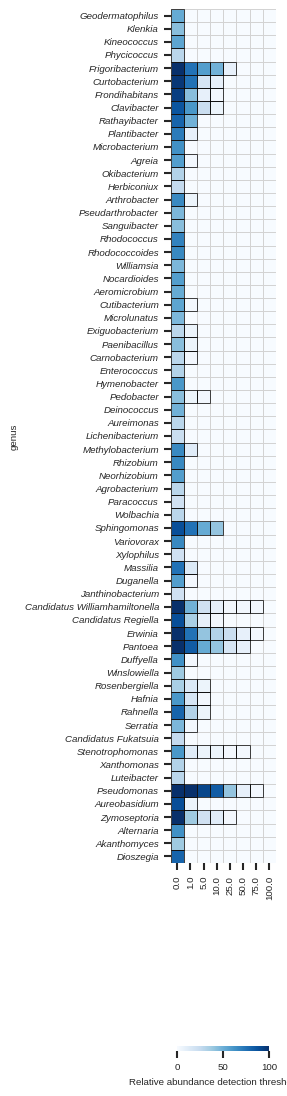

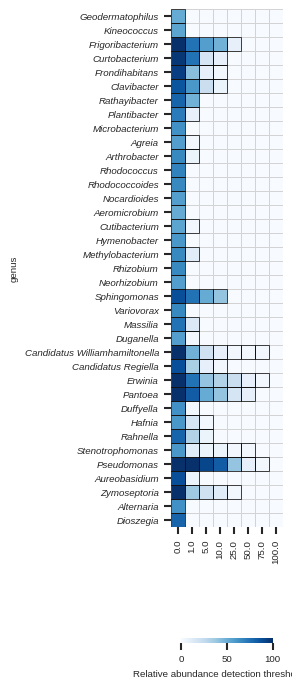

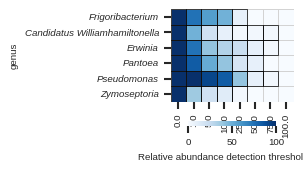

150
85 56.7 ['Achromobacter', 'Acidovorax', 'Acinetobacter', 'Agrococcus', 'Allomeiothermus', 'Aspergillus', 'Bifidobacterium', 'Blautia', 'Bradyrhizobium', 'Brevibacterium', 'Brevundimonas', 'Burkholderia', 'Buttiauxella', 'Candidatus Tisiphia', 'Cellulomonas', 'Chryseobacterium', 'Citrobacter', 'Comamonas', 'Corynebacterium', 'Dyadobacter', 'Enterobacter', 'Epilithonimonas', 'Ferranicluibacter', 'Filobasidium', 'Flavobacterium', 'Fusarium', 'Humibacillus', 'Izhakiella', 'Klebsiella', 'Kluyvera', 'Knoellia', 'Kocuria', 'Lactobacillus', 'Lactococcus', 'Latilactobacillus', 'Lawsonella', 'Leifsonia', 'Lelliottia', 'Leuconostoc', 'Limosilactobacillus', 'Lonsdalea', 'Lysinibacillus', 'Malassezia', 'Marmoricola', 'Merdimonas', 'Methylorubrum', 'Micrococcus', 'Moellerella', 'Morganella', 'Mycolicibacterium', 'Noviherbaspirillum', 'Novosphingobium', 'Obesumbacterium', 'Ornithinimicrobium', 'Paenarthrobacter', 'Paenimyroides', 'Paraburkholderia', 'Pararhizobium', 'Pedococcus', 'Peribacillus', 

In [19]:
# Detection thresholds
thresholds = [0, 1 , 5, 10 , 100*1/4, 100*1/2, 100*3/4, 100*1]
sorting_ranks=['superkingdom', 'phylum', 'class', 'order', 'family', "genus", "species"]

common_bacterial_genus,core_bacterial_genus,ubiquitous_bacterial_genus,prevalence_bacterial_taxa=prevalence_groups(microbial_genus_df_relative, "genus")


### 3.2 Figure 3a. Phylogenetic Placement of Common, Core, and Ubiquitous Genera


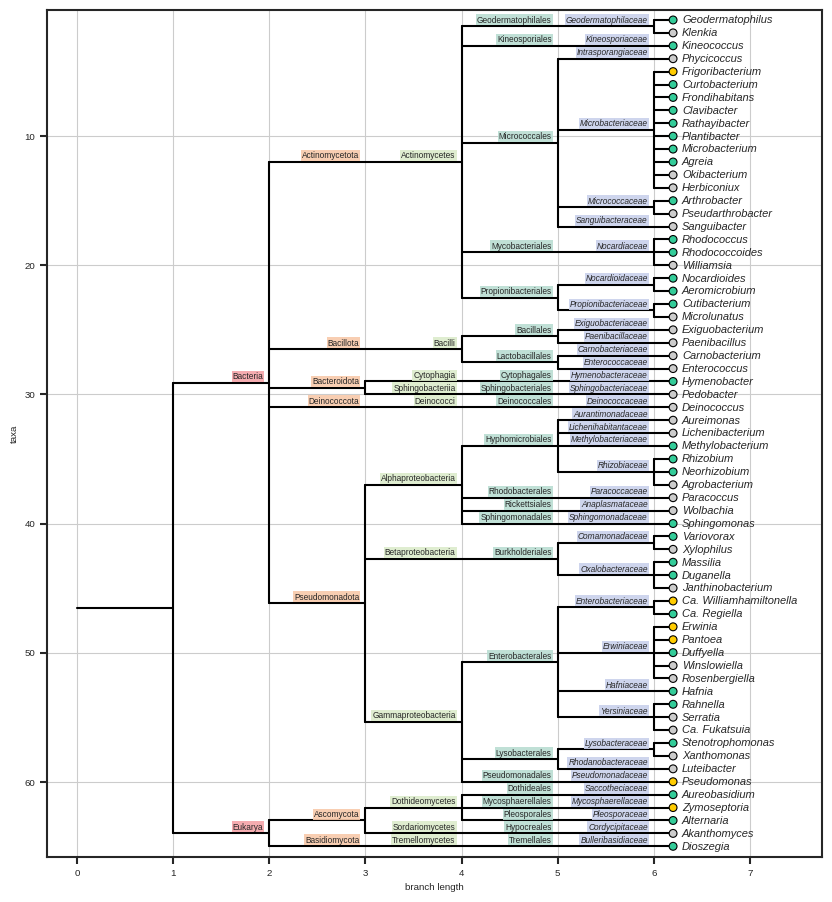

In [20]:
common_with_tax = prevalence_bacterial_taxa.loc[common_bacterial_genus.index.to_list()].reset_index()
common_with_tax
# Taxonomic levels used for the display tree
levels=['superkingdom', 'phylum', 'class', 'order', 'family', "genus"]

# Build Newick tree
tree = build_nested_tree(common_with_tax, levels)
newick_str = to_newick(tree)

# Convert Newick string to Phylo tree
handle = StringIO(newick_str)
tree = Phylo.read(handle, "newick")

# Shorten the terminal family-to-genus branches.
for clade in tree.find_clades():
    clade.branch_length = 0.20 if clade.is_terminal() else 1

# Create a figure with the desired size
fig, ax = plt.subplots(figsize=(10, 11))  # Adjust width and height here

def get_phylo_positions(tree):
    x_posns = tree.depths()
    if not max(x_posns.values()):
        x_posns = tree.depths(unit_branch_lengths=True)
    maxheight = tree.count_terminals()
    y_posns = {
        tip: maxheight - i for i, tip in enumerate(reversed(tree.get_terminals()))
    }

    def calc_row(clade):
        for subclade in clade:
            if subclade not in y_posns:
                calc_row(subclade)
        y_posns[clade] = (y_posns[clade.clades[0]] + y_posns[clade.clades[-1]]) / 2.0

    if tree.root.clades:
        calc_row(tree.root)
    return x_posns, y_posns

# Draw the tree structure without labels; labels are placed manually below.
Phylo.draw(tree, axes=ax, do_show=False, label_func=lambda clade: None)

for text in ax.texts:
    text.set_fontsize(8)
    text.set_fontstyle("italic")

# Add internal taxonomy labels beside their clade nodes instead of at the right tip-label position.
x_posns, y_posns = get_phylo_positions(tree)
label_offset = max(x_posns.values()) * 0.01
genus_label_offset = max(x_posns.values()) * 0.015

prevalence_group_colors = {
    "common": "#CCCCCC",
    "core": "#33CC99",
    "ubiquitous": "#FFCC00",
}

def clean_taxon_label(label):
    return label.replace("Candidatus", "Ca.").replace("Canditatus", "Ca.")

def genus_prevalence_group(genus):
    if genus in ubiquitous_bacterial_genus.index:
        return "ubiquitous"
    if genus in core_bacterial_genus.index:
        return "core"
    if genus in common_bacterial_genus.index:
        return "common"
    return "common"

def is_family_clade(clade):
    return (not clade.is_terminal()) and any(child.is_terminal() for child in clade.clades)

rank_background_colors = {
    "superkingdom": "#F4A3A8",
    "phylum": "#F8C9AA",
    "class": "#DCECCB",
    "order": "#B9DDD2",
    "family": "#C9D1EB",
}

def taxonomic_rank(clade):
    if clade == tree.root:
        return levels[0]
    rank_idx = len(tree.get_path(clade)) - 1
    return levels[rank_idx] if rank_idx < len(levels) else None

# Add terminal/genus labels with padding after the endpoint circles.
for clade in tree.get_terminals():
    if clade.name:
        ax.text(
            x_posns[clade] + genus_label_offset,
            y_posns[clade],
            clean_taxon_label(clade.name),
            fontsize=8,
            fontstyle="italic",
            horizontalalignment="left",
            verticalalignment="center",
        )

for clade in tree.find_clades():
    if clade.name and not clade.is_terminal():
        rank = taxonomic_rank(clade)
        ax.text(
            x_posns[clade] - label_offset,
            y_posns[clade] - 0.5,
            clean_taxon_label(clade.name),
            fontsize=6,
            fontstyle="italic" if is_family_clade(clade) else "normal",
            horizontalalignment="right",
            verticalalignment="center",
            bbox=dict(facecolor=rank_background_colors.get(rank, "white"), edgecolor="none", boxstyle="square,pad=0.12", alpha=0.9),
        )

# Mark terminal/genus endpoints with circles.
terminal_clades = tree.get_terminals()
ax.scatter(
    [x_posns[clade] for clade in terminal_clades],
    [y_posns[clade] for clade in terminal_clades],
    s=32,
    c=[prevalence_group_colors[genus_prevalence_group(clade.name)] for clade in terminal_clades],
    edgecolors="black",
    linewidths=0.8,
    zorder=5,
)

# Add title and save
plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/3a_common_core_ubiquitous_genera_phylogeny.svg", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)



### 3.3 Figure 3c. Mean Relative Abundance of Common Genera


/tmp/ipykernel_196344/2745813021.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


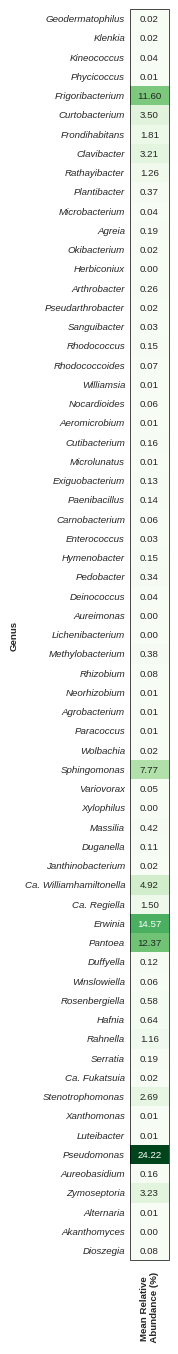

In [21]:
microbial_df_tax_genus=microbial_df_tax.groupby("genus").first().reset_index()
mean_relative_plot=common_bacterial_genus.reset_index().merge(microbial_df_tax_genus, left_on="genus", right_on="genus", how="left").round(2).set_index("genus")[["mean"]]
mean_relative_plot


plt.figure(figsize=(0.5, len(mean_relative_plot) * 0.25))  # adjust height to number of genera

ax = sns.heatmap(
    mean_relative_plot,
    annot=True,          # show numbers
    fmt=".2f",           # 2 decimal places
    cmap="Greens",       # green color scale
    cbar=False,
    annot_kws={"fontsize": 7},
)

ax.set_xlabel("Mean Relative\n Abundance (%)", fontweight="bold", rotation=90)
ax.set_ylabel("Genus", fontweight="bold",)
ax.set_xticklabels([])

ax.set_yticklabels([label.get_text().replace("Candidatus", "Ca.").replace("Canditatus", "Ca.") for label in ax.get_yticklabels()])
for tick_label in ax.get_yticklabels():
    tick_label.set_fontstyle("italic")
    
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)

ax.add_patch(plt.Rectangle((0, 0), mean_relative_plot.shape[1], mean_relative_plot.shape[0], fill=False, edgecolor="black", linewidth=0.5, clip_on=False))

plt.tight_layout()
plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/3c_common_genera_mean_relative_abundance.svg", format="svg")
plt.show()

### 3.4 Figure 3d. Strain-Level Richness Across Genera


/tmp/ipykernel_196344/3594347624.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


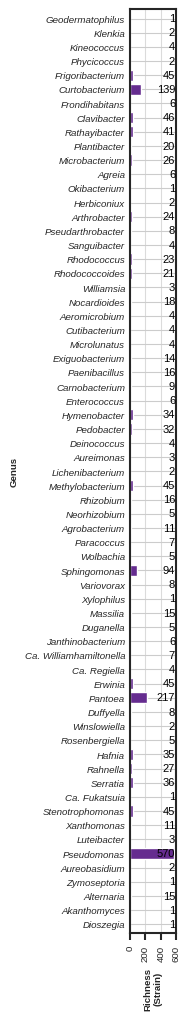

,species
genus,
Pseudomonas,570
Pantoea,217
Curtobacterium,139
Sphingomonas,94
Clavibacter,46
...,...
Staphylococcus,1
Sphingobium,1
Vairimorpha,1


In [22]:
# richess_strainsmicrobial_df_counts_tax[desired_ranks].groupby("species").first().reset_index()[["species", "genus"]].groupby("genus").count().sort_values("species")
richness_strain=microbial_df_counts_tax[desired_ranks][["species", "genus"]].groupby("genus").count()
filtered_richness=richness_strain.loc[common_bacterial_genus.index]
filtered_richness = filtered_richness.iloc[::-1]

ax = filtered_richness["species"].plot(
    kind="barh",
    color="#652C8F",
    figsize=(0.6, 12),
    width=0.8  # wider bars
)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_width())),
        (0.97, p.get_y() + p.get_height() / 2),
        xycoords=(ax.transAxes, ax.transData),
        ha="right",
        va="center",
        fontsize=8,
        color="black"
    )

ax.set_xlabel("Richness\n(Strain)", rotation=90, fontweight="bold")
ax.set_ylabel("Genus", fontweight="bold")
ax.set_yticklabels([label.get_text().replace("Candidatus", "Ca.").replace("Canditatus", "Ca.") for label in ax.get_yticklabels()])
for tick_label in ax.get_yticklabels():
    tick_label.set_fontstyle("italic")
ax.tick_params(axis="y", length=0)

ax.set_xticks([0, 200, 400, 600])
ax.set_xlim(0,600)

ax.grid(axis="x", linestyle="-", alpha=0.7)
ax.set_axisbelow(True)
ax.set_xticklabels(ax.get_xticks(), rotation=90)

plt.tight_layout()
plt.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/3d_genus_strain_level_richness.svg", format="svg")
plt.show()
display(richness_strain.sort_values("species", ascending=False))


## 4. Supplementary Tables

### Supplementary Table 10. Genus-Level Taxonomy and Prevalence of the Microbial Fraction


In [23]:
sup_10_df=prevalence_bacterial_taxa.reset_index().merge(richness_strain, left_on="genus", right_index=True).round(2)
sup_10_df["% strains"] = (sup_10_df["species"] / sup_10_df["species"].sum() * 100).round(1).astype(str) + "%"
sup_10_df=sup_10_df.sort_values("species", ascending=False).reset_index(drop=True)
sup_10_df.index = sup_10_df.index + 1
sup_10_df=sup_10_df.rename(columns={"mean": "mean relative abundance", "std": "mean relative abundance std", "species": "strain richness", "category": "Prevalence group"})
sup_10_columns=["genus", "mean relative abundance", "mean relative abundance std", "strain richness", "% strains", "Prevalence group"] + thresholds + ["superkingdom", "phylum", "class", "order", "family"]
sup_10_df=sup_10_df[sup_10_columns]
sup_10_df.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/S10_genus_taxonomy_prevalence_microbial_fraction.csv")
sup_10_df

,genus,mean relative abundance,mean relative abundance std,strain richness,% strains,Prevalence group,0.0,1.0,5.0,10.0,25.0,50.0,75.0,100.0,superkingdom,phylum,class,order,family
1,Pseudomonas,24.22,18.03,570,28.2%,ubiquitous,100.00,100.00,91.43,82.86,40.00,8.57,2.86,0.0,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae
2,Pantoea,12.37,16.82,217,10.8%,ubiquitous,100.00,82.86,51.43,40.00,17.14,8.57,0.00,0.0,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Erwiniaceae
3,Curtobacterium,3.50,5.03,139,6.9%,core,97.14,74.29,17.14,8.57,0.00,0.00,0.00,0.0,Bacteria,Actinomycetota,Actinomycetes,Micrococcales,Microbacteriaceae
4,Sphingomonas,7.77,7.04,94,4.7%,core,88.57,74.29,51.43,40.00,0.00,0.00,0.00,0.0,Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae
5,Clavibacter,3.21,3.73,46,2.3%,core,85.71,60.00,22.86,5.71,0.00,0.00,0.00,0.0,Bacteria,Actinomycetota,Actinomycetes,Micrococcales,Microbacteriaceae
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,Staphylococcus,0.00,0.00,1,0.0%,unique,2.86,0.00,0.00,0.00,0.00,0.00,0.00,0.0,Bacteria,Bacillota,Bacilli,Bacillales,Staphylococcaceae
147,Sphingobium,0.00,0.00,1,0.0%,unique,2.86,0.00,0.00,0.00,0.00,0.00,0.00,0.0,Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae
148,Vairimorpha,0.00,0.00,1,0.0%,unique,2.86,0.00,0.00,0.00,0.00,0.00,0.00,0.0,Eukarya,Microsporidia,None,None,Nosematidae
149,Xylophilus,0.00,0.00,1,0.0%,common,20.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,Bacteria,Pseudomonadota,Betaproteobacteria,Burkholderiales,Comamonadaceae


## 5. Supplementary Figures

### Supplementary Figure 2. Base Classification From the Microbial Fraction


150


,strain collection,non strain collection,plant,unclassified
Sample,,,,
bNWd,0.4,66.1,6.5,27.0
bSEd,4.5,77.6,0.0,17.9
bSWd,3.3,44.7,0.4,51.7
bFL,3.2,49.6,0.2,47.0
bOL,1.5,55.1,0.1,43.4
bN1,13.9,42.9,19.7,23.5
bN2,3.4,2.5,78.0,16.2
bN3,6.0,1.9,77.4,14.7
bZ1,1.9,0.6,83.2,14.3


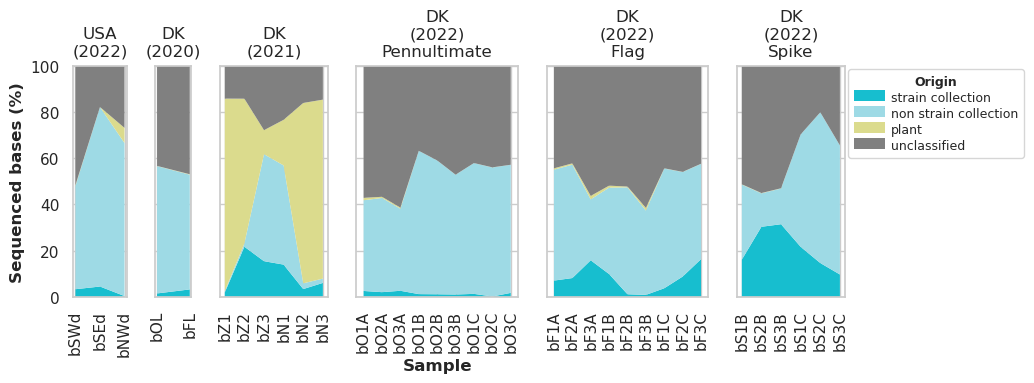

In [38]:
strain_list=pd.read_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/SOURMASH/taxonomy/taxonomy_strains.csv")["ident"].to_list()
print(len(strain_list))

strain_collection_counts_df=microbial_df_counts[microbial_df_counts.index.isin(strain_list)].sum().to_frame()
strain_collection_counts_df.columns=["strain_collection_counts"]
strain_collection_counts_df

non_strain_collection_counts_df=microbial_df_counts[~microbial_df_counts.index.isin(strain_list)].sum().to_frame()
non_strain_collection_counts_df.columns=["non_strain_collection_counts"]


df_reads_strain=df_reads.merge(strain_collection_counts_df, left_on="Sample", right_index=True).merge(non_strain_collection_counts_df, left_on="Sample", right_index=True).set_index("Sample")#/1000000
df_reads_strain["plant"]=df_reads_strain["total"]-df_reads_strain["strain_collection_counts"]-df_reads_strain["unclassified"]-df_reads_strain["non_strain_collection_counts"]

df_reads_strain["p_strain_collection"]=df_reads_strain["strain_collection_counts"]*100/df_reads_strain["total"]
df_reads_strain["p_unclassified"]=df_reads_strain["unclassified"]*100/df_reads_strain["total"]
df_reads_strain["p_non_strain_collection"]=df_reads_strain["non_strain_collection_counts"]*100/df_reads_strain["total"]
df_reads_strain["p_plant"]=df_reads_strain["plant"]*100/df_reads_strain["total"]
df_reads_strain["sum_p"]=df_reads_strain["p_plant"]+df_reads_strain["p_unclassified"]+df_reads_strain["p_non_strain_collection"] + df_reads_strain["p_strain_collection"]
df_reads_strain=df_reads_strain[df_reads_strain.index.isin(SAMPLES)][["p_strain_collection","p_non_strain_collection", "p_plant", "p_unclassified"]]
df_reads_strain.columns=["strain collection","non strain collection", "plant", "unclassified"]
df_reads_strain.to_csv("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/microbial_fraction_base_classification.csv")

display(df_reads_strain.round(1))
plot_stackplot_dict_reads(df_reads_strain, group_dict, "/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/SFigure2_microbial_fraction_base_classification_with_strain_collection.svg",)


### Supplementary Figure 3. Sourmash Abundance Profiles


#### Grouped Taxonomic Profiles


14


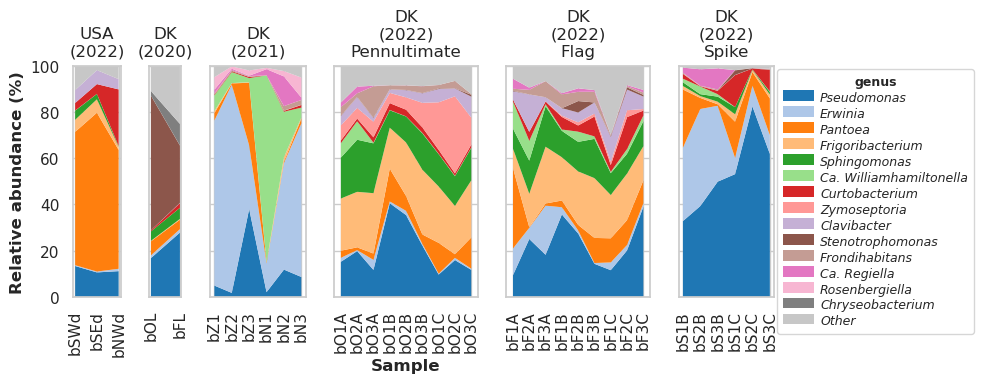

In [39]:
fig, axes = plot_stackplot_dict(filter_top_taxa_particles(microbial_genus_df_relative.T.loc[SAMPLES],3), group_dict, figsize=(10, 4), show=False)
fig.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/SFigure3_sourmash_genus_abundance_profiles_grouped.svg")
plt.show()

8


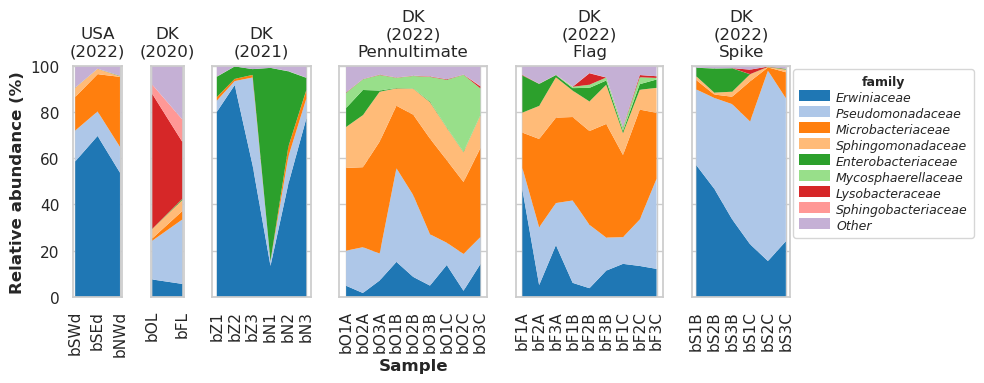

In [26]:
fig, axes = plot_stackplot_dict(filter_top_taxa_particles(microbial_family_df_relative.T.loc[SAMPLES],3), group_dict, figsize=(10, 4), show=False)
fig.savefig("/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/Relative_Abundance_Family.svg")
plt.show()

### Supplementary Figure 4. Rank-Cumulative Relative Abundance of Microbial Genera


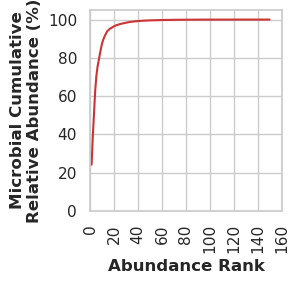

In [27]:
linewidth = 1.5

# Prepare data
genus_mean = microbial_genus_df_relative.mean(axis=1)

df_sorted = (
    genus_mean.sort_values(ascending=False)
    .to_frame("mean_relative")
    .reset_index()
    .rename(columns={"index": "Genus"})
)

df_sorted["rank"] = range(1, len(df_sorted) + 1)

df_sorted["cumulative_relative"] = (
    df_sorted["mean_relative"].cumsum()
    / df_sorted["mean_relative"].sum()
) * 100


# Plot (match aesthetics, no subplot grid)
xlim = min(700, len(df_sorted))  # or remove min() if you want full range

plt.figure(figsize=(3.15,3))

plt.plot(
    df_sorted["rank"],
    df_sorted["cumulative_relative"],
    linestyle='-',
    lw=linewidth,
    color="#CC3333"
)

plt.ylim(0, 105)
plt.xlim(0, 160)

plt.xlabel("Abundance Rank", fontweight="bold")
plt.ylabel("Microbial Cumulative\nRelative Abundance (%)", fontweight="bold")

plt.grid(True)

plt.xticks(range(0, 180, 20), rotation=90)

plt.tight_layout()

plt.savefig(
    "/home/lmf/PhylloVir/VIRAL_WORLD/BACTERIAL_FRACTION/FIGURES_AND_TABLES/SFigure4_rank_cumulative_relative_abundance_microbial_genera.svg",
    bbox_inches="tight"
)

plt.show()
